<a href="https://colab.research.google.com/github/Ghalaahmed/Algorithm-Analysis-and-Design/blob/main/CSC301_Phishing_Detection_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phishing Website Detection
## Decision Tree vs Logistic Regression

This notebook implements a phishing website detection system using two machine learning algorithms: **Decision Tree** and **Logistic Regression**.

The goal is to classify websites as phishing or legitimate based on extracted website features. Both algorithms are trained on the same dataset and compared in terms of accuracy and execution time.

The execution time is reported in **milliseconds**, and the experiments are repeated using different random samples to calculate the average running time.

## 1. Import Libraries

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 2. Load Dataset

In [2]:
df = pd.read_csv("phishing.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## 3. Data Check

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


## 4. Prepare Features and Target

In [4]:
# Drop Index column because it is only an identifier and not a real website feature
if "Index" in df.columns:
    df = df.drop("Index", axis=1)

X = df.drop("class", axis=1)
y = df["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11054, 30)
Target shape: (11054,)


## 5. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Decision Tree Model

In [6]:
start = time.time()

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

end = time.time()

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_time_ms = (end - start) * 1000

print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("Execution Time (ms):", round(dt_time_ms, 4))

Decision Tree Accuracy: 0.9602
Execution Time (ms): 31.2071


## 7. Logistic Regression Model

In [7]:
start = time.time()

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

end = time.time()

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_time_ms = (end - start) * 1000

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Execution Time (ms):", round(lr_time_ms, 4))

Logistic Regression Accuracy: 0.9335
Execution Time (ms): 74.0473


## 8. Results Comparison

In [8]:
results = pd.DataFrame({
    "Algorithm": ["Decision Tree", "Logistic Regression"],
    "Accuracy": [dt_accuracy, lr_accuracy],
    "Execution Time (ms)": [dt_time_ms, lr_time_ms]
})

results

,Algorithm,Accuracy,Execution Time (ms)
0,Decision Tree,0.960199,31.207085
1,Logistic Regression,0.933514,74.047327


## 9. Experiments with Different Dataset Sizes

The models are tested using three different dataset sizes: **1000, 5000, and 10000 samples**.

For each size, the experiment is repeated several times using different random samples. This produces a more reliable average execution time for each value of n.

In [16]:
sizes = [1000, 5000, 10000]

for size in sizes:

    subset = df.sample(n=size, random_state=42)

    X = subset.drop("class", axis=1)
    y = subset["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ===== Decision Tree =====
    start = time.time()

    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)

    end = time.time()

    dt_accuracy = accuracy_score(y_test, y_pred_dt)
    dt_time_ms = (end - start) * 1000

    # ===== Logistic Regression =====
    start = time.time()

    lr = LogisticRegression(max_iter=5000)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)

    end = time.time()

    lr_accuracy = accuracy_score(y_test, y_pred_lr)
    lr_time_ms = (end - start) * 1000

    print("Dataset size:", size)
    print("Decision Tree Accuracy:", round(dt_accuracy, 4))
    print("Decision Tree Time (ms):", round(dt_time_ms, 4))
    print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
    print("Logistic Regression Time (ms):", round(lr_time_ms, 4))
    print("---------------------------")

Dataset size: 1000
Decision Tree Accuracy: 0.88
Decision Tree Time (ms): 19.762
Logistic Regression Accuracy: 0.905
Logistic Regression Time (ms): 21.3141
---------------------------
Dataset size: 5000
Decision Tree Accuracy: 0.94
Decision Tree Time (ms): 63.3948
Logistic Regression Accuracy: 0.93
Logistic Regression Time (ms): 74.8324
---------------------------
Dataset size: 10000
Decision Tree Accuracy: 0.965
Decision Tree Time (ms): 45.5878
Logistic Regression Accuracy: 0.93
Logistic Regression Time (ms): 105.8688
---------------------------


## 10. Average Accuracy and Average Running Time

In [10]:
average_results = experiment_df.groupby(["Dataset Size", "Algorithm"], as_index=False).agg({
    "Accuracy": "mean",
    "Execution Time (ms)": "mean"
})

average_results["Accuracy"] = average_results["Accuracy"].round(4)
average_results["Execution Time (ms)"] = average_results["Execution Time (ms)"].round(4)

average_results

,Dataset Size,Algorithm,Accuracy,Execution Time (ms)
0,1000,Decision Tree,0.9190,7.6149
1,1000,Logistic Regression,0.9110,13.8443
2,5000,Decision Tree,0.9450,21.0670
3,5000,Logistic Regression,0.9258,31.4794
4,10000,Decision Tree,0.9599,30.8950
5,10000,Logistic Regression,0.9233,43.3141


## 11. Best, Worst, and Average Accuracy

In [11]:
# Store accuracy results for each dataset size

decision_tree_results = []
logistic_regression_results = []

sizes = [1000, 5000, 10000]

for size in sizes:

    # Take subset from dataset
    subset = df.sample(n=size, random_state=42)

    X = subset.drop("class", axis=1)
    y = subset["class"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ===== Decision Tree =====
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)

    y_pred_dt = dt.predict(X_test)

    dt_accuracy = accuracy_score(y_test, y_pred_dt)

    # Save result
    decision_tree_results.append(dt_accuracy)

    # ===== Logistic Regression =====
    lr = LogisticRegression(max_iter=5000)
    lr.fit(X_train, y_train)

    y_pred_lr = lr.predict(X_test)

    lr_accuracy = accuracy_score(y_test, y_pred_lr)

    # Save result
    logistic_regression_results.append(lr_accuracy)


# ===== Calculate Best / Worst / Average =====

dt_best = max(decision_tree_results)
dt_worst = min(decision_tree_results)
dt_average = sum(decision_tree_results) / len(decision_tree_results)

lr_best = max(logistic_regression_results)
lr_worst = min(logistic_regression_results)
lr_average = sum(logistic_regression_results) / len(logistic_regression_results)


# ===== Print Final Results =====

print("=== Decision Tree ===")
print("Best Case:", round(dt_best, 3))
print("Worst Case:", round(dt_worst, 3))
print("Average Case:", round(dt_average, 3))

print("\n=== Logistic Regression ===")
print("Best Case:", round(lr_best, 3))
print("Worst Case:", round(lr_worst, 3))
print("Average Case:", round(lr_average, 3))


# ===== Final Comparison =====

print("\nConclusion:")

if dt_average > lr_average:
    print("Decision Tree achieved better overall performance.")
else:
    print("Logistic Regression achieved better overall performance.")

=== Decision Tree ===
Best Case: 0.965
Worst Case: 0.88
Average Case: 0.928

=== Logistic Regression ===
Best Case: 0.93
Worst Case: 0.905
Average Case: 0.922

Conclusion:
Decision Tree achieved better overall performance.


## 12. Best, Worst, and Average Accuracy Table

In [12]:
best_worst_average = pd.DataFrame({
    "Algorithm": ["Decision Tree", "Logistic Regression"],
    "Best Accuracy": [dt_best, lr_best],
    "Worst Accuracy": [dt_worst, lr_worst],
    "Average Accuracy": [dt_average, lr_average]
})

best_worst_average[["Best Accuracy", "Worst Accuracy", "Average Accuracy"]] = best_worst_average[
    ["Best Accuracy", "Worst Accuracy", "Average Accuracy"]
].round(4)

best_worst_average

,Algorithm,Best Accuracy,Worst Accuracy,Average Accuracy
0,Decision Tree,0.965,0.880,0.9283
1,Logistic Regression,0.930,0.905,0.9217


## 13. Running Time and Growth Order Diagram

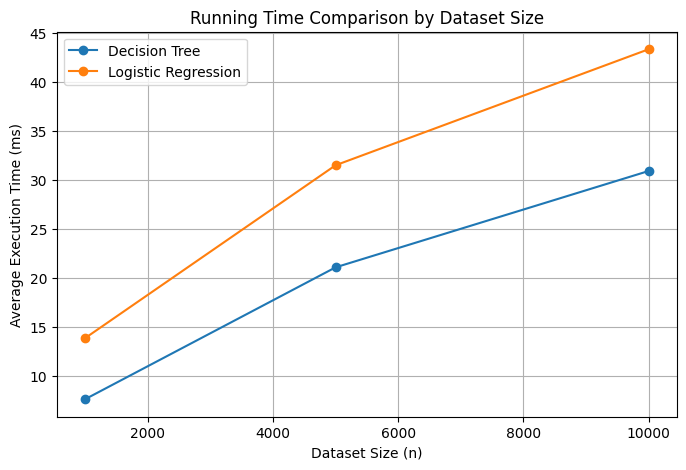

In [13]:
# Prepare data for plotting
dt_plot = average_results[average_results["Algorithm"] == "Decision Tree"]
lr_plot = average_results[average_results["Algorithm"] == "Logistic Regression"]

plt.figure(figsize=(8, 5))
plt.plot(dt_plot["Dataset Size"], dt_plot["Execution Time (ms)"], marker="o", label="Decision Tree")
plt.plot(lr_plot["Dataset Size"], lr_plot["Execution Time (ms)"], marker="o", label="Logistic Regression")

plt.xlabel("Dataset Size (n)")
plt.ylabel("Average Execution Time (ms)")
plt.title("Running Time Comparison by Dataset Size")
plt.legend()
plt.grid(True)
plt.show()

## 14. Accuracy Comparison Diagram

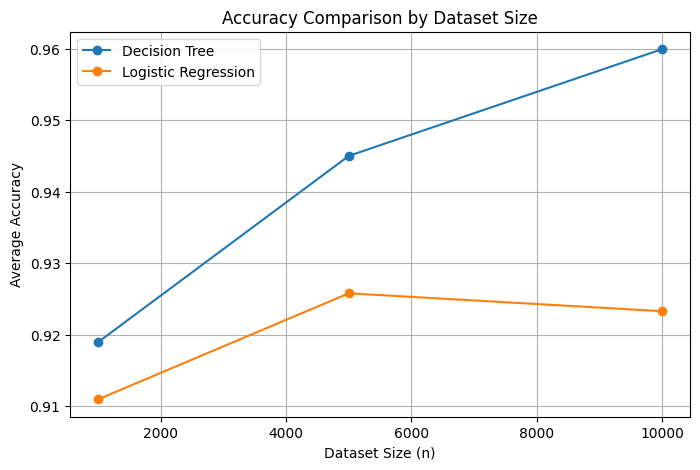

In [14]:
dt_acc_plot = average_results[average_results["Algorithm"] == "Decision Tree"]
lr_acc_plot = average_results[average_results["Algorithm"] == "Logistic Regression"]

plt.figure(figsize=(8, 5))
plt.plot(dt_acc_plot["Dataset Size"], dt_acc_plot["Accuracy"], marker="o", label="Decision Tree")
plt.plot(lr_acc_plot["Dataset Size"], lr_acc_plot["Accuracy"], marker="o", label="Logistic Regression")

plt.xlabel("Dataset Size (n)")
plt.ylabel("Average Accuracy")
plt.title("Accuracy Comparison by Dataset Size")
plt.legend()
plt.grid(True)
plt.show()

## 15. Final Conclusion

In [15]:
dt_overall_accuracy = average_results[average_results["Algorithm"] == "Decision Tree"]["Accuracy"].mean()
lr_overall_accuracy = average_results[average_results["Algorithm"] == "Logistic Regression"]["Accuracy"].mean()

dt_overall_time = average_results[average_results["Algorithm"] == "Decision Tree"]["Execution Time (ms)"].mean()
lr_overall_time = average_results[average_results["Algorithm"] == "Logistic Regression"]["Execution Time (ms)"].mean()

print("Overall Decision Tree Accuracy:", round(dt_overall_accuracy, 4))
print("Overall Logistic Regression Accuracy:", round(lr_overall_accuracy, 4))
print("Overall Decision Tree Time (ms):", round(dt_overall_time, 4))
print("Overall Logistic Regression Time (ms):", round(lr_overall_time, 4))

print("\nFinal Conclusion:")

if dt_overall_accuracy > lr_overall_accuracy and dt_overall_time < lr_overall_time:
    print("Decision Tree performed better overall because it achieved higher accuracy and lower execution time.")
elif dt_overall_accuracy > lr_overall_accuracy:
    print("Decision Tree performed better in terms of accuracy.")
elif lr_overall_accuracy > dt_overall_accuracy:
    print("Logistic Regression performed better in terms of accuracy.")
else:
    print("Both algorithms achieved similar accuracy, so execution time should be used for comparison.")

Overall Decision Tree Accuracy: 0.9413
Overall Logistic Regression Accuracy: 0.92
Overall Decision Tree Time (ms): 19.859
Overall Logistic Regression Time (ms): 29.5459

Final Conclusion:
Decision Tree performed better overall because it achieved higher accuracy and lower execution time.
